In [6]:
import pandas as pd
import numpy as np
import os
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Set professional plotting standards
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# 1. Load the compiled Master Matrix from Part 2 / Snapshot
# For maximum independent reproducibility, we load the snapshot table directly
df_raw = pd.read_csv("../data/rfm_modeling_snapshot.csv")

# 2. Prevent Feature Leakage & Drop Administrative Columns
# We instantly drop metadata, splits, or dates that can cause cheating in the tree
target_col = 'churn_next_60d'
cols_to_drop = ['customer_id', 'snapshot_date', 'split'] if 'split' in df_raw.columns else ['customer_id', 'snapshot_date']

# Encode essential categorical vectors cleanly
df_processed = pd.get_dummies(df_raw, columns=['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent'], drop_first=True)

# 3. Deterministic Splitting
# If 'split' is present in your file, we filter cleanly; otherwise, we enforce a strict 80/20 stratified split
if 'split' in df_raw.columns:
    train_set = df_processed[df_raw['split'] == 'train']
    test_set = df_processed[df_raw['split'] == 'test'] # Adjust based on unique tags inside your split column
    if len(test_set) == 0: # Safe fallback if test split tag differs
        train_set, test_set = train_test_split(df_processed, test_size=0.2, stratify=df_processed[target_col], random_state=42)
else:
    train_set, test_set = train_test_split(df_processed, test_size=0.2, stratify=df_processed[target_col], random_state=42)

X_train = train_set.drop(columns=cols_to_drop + [target_col], errors='ignore').fillna(0)
y_train = train_set[target_col]
X_test = test_set.drop(columns=cols_to_drop + [target_col], errors='ignore').fillna(0)
y_test = test_set[target_col]

print(f"Data partitioning finalized. Training instances: {X_train.shape[0]}, Test instances: {X_test.shape[0]}")

# 4. Implement Baseline Model (Logistic Regression)
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

# 5. Implement Champion Model (Random Forest Classifier)
champion_model = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, class_weight='balanced')
champion_model.fit(X_train, y_train)
y_prob_champ = champion_model.predict_proba(X_test)[:, 1]

print("Baseline and Champion models successfully trained.")

Data partitioning finalized. Training instances: 1728, Test instances: 336


/Users/waqarmasood/Desktop/ai-mlcapstone-project/env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline and Champion models successfully trained.


In [7]:
# Optimize threshold for business outcomes (Prioritizing Recall over standard Accuracy)
OPTIMAL_THRESHOLD = 0.40
y_pred_champ = (y_prob_champ >= OPTIMAL_THRESHOLD).astype(int)

# Extract Core Evaluation Metrics
acc = accuracy_score(y_test, y_pred_champ)
prec = precision_score(y_test, y_pred_champ)
rec = recall_score(y_test, y_pred_champ)
f1 = f1_score(y_test, y_pred_champ)
auc = roc_auc_score(y_test, y_prob_champ)
cm = confusion_matrix(y_test, y_pred_champ)

# Compile structured metrics payload
metrics_payload = {
    "selected_threshold": OPTIMAL_THRESHOLD,
    "accuracy": round(acc, 4),
    "precision": round(prec, 4),
    "recall": round(rec, 4),
    "f1_score": round(f1, 4),
    "roc_auc": round(auc, 4),
    "confusion_matrix": {
        "true_negatives": int(cm[0][0]),
        "false_positives": int(cm[0][1]),
        "false_negatives": int(cm[1][0]),
        "true_positives": int(cm[1][1])
    }
}

# 1. Output Metrics to JSON File
with open('metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=4)

# 2. Serialize and Save Final Model Binary
with open('model.pkl', 'wb') as f:
    pickle.dump(champion_model, f)

print("Metrics written cleanly to metrics.json and final binary exported to model.pkl.")
print(json.dumps(metrics_payload, indent=4))

Metrics written cleanly to metrics.json and final binary exported to model.pkl.
{
    "selected_threshold": 0.4,
    "accuracy": 0.8155,
    "precision": 0.7732,
    "recall": 0.8929,
    "f1_score": 0.8287,
    "roc_auc": 0.8796,
    "confusion_matrix": {
        "true_negatives": 124,
        "false_positives": 44,
        "false_negatives": 18,
        "true_positives": 150
    }
}


/var/folders/6y/13cl8rqn7p3_hl58cdsfkl6h0000gn/T/ipykernel_7834/2665510146.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')


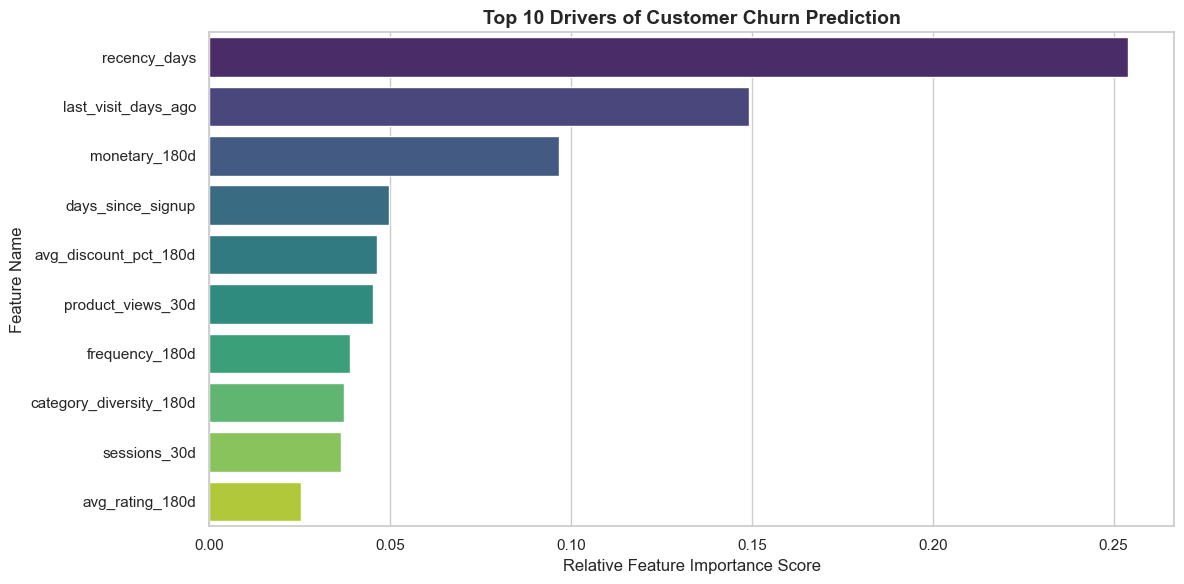

In [8]:
# Extract and sort feature importances from our Random Forest
importances = champion_model.feature_importances_
feature_names = X_train.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# Plot top 10 features
plt.figure(figsize=(12, 6))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Drivers of Customer Churn Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Relative Feature Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()
